In [36]:
#import statements
import os
os.chdir("..")
from pathlib import Path
from typing import List, Dict, Optional, Union
from t2Interp.T2I import T2IModel
from t2Interp.intervention import EncoderAttentionIntervention, ScalingAttentionIntervention #, InterventionRunner
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt
import seaborn
from datasets import load_dataset
from tqdm import tqdm
from torchvision import transforms
import torchvision

In [2]:
#Here's the classifier 
class K_Steering:
    def __init__(self, input_dim, num_classes=6, hidden_dim=256, lr=1e-3, device='cuda'):
        """
        Parameters:
          - input_dim: dimensionality of your raw activations.
          - num_classes: number of tone classes to classify.
          - hidden_dim: size of the hidden layer in the MLP.
          - lr: learning rate for training the classifier.
          - device: 'cuda' or 'cpu'.
        """
        self.device = device
        self.num_classes = num_classes
        
        # Define a multi-class MLP classifier
        self.classifier = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_classes)  # outputs logits for each tone class
        ).to(device)
        
        self.optimizer = optim.Adam(self.classifier.parameters(), lr=lr)
        self.loss_fn = nn.CrossEntropyLoss()
        
        # Store class names for reference
        self.class_names = None
        

    def fit(self, activations_dict, epochs=30, batch_size=32, class_weights=None, val_split=0.2):
        """
        Train the multiclass classifier on raw activations.

        Parameters:
          - activations_dict: Dictionary mapping class names to NumPy arrays of activations.
          - epochs: number of training epochs.
          - batch_size: training batch size.
          - class_weights: Optional tensor of weights for each class to handle imbalance.
          - val_split: Fraction of data to use for validation (default: 0.2)
        """
        self.class_names = list(activations_dict.keys())
        assert len(self.class_names) == self.num_classes, f"Expected {self.num_classes} classes, got {len(self.class_names)}"
        
        # Prepare data and split train/val
        X_list = []
        y_list = []
        
        for i, class_name in enumerate(self.class_names):
            X_class = torch.tensor(activations_dict[class_name], dtype=torch.float32, device=self.device)
            y_class = torch.full((X_class.size(0),), i, dtype=torch.long, device=self.device)
            X_list.append(X_class)
            y_list.append(y_class)
        
        X = torch.cat(X_list, dim=0)
        y = torch.cat(y_list, dim=0)
        
        # Split train/val
        n_total = X.size(0)
        n_val = int(n_total * val_split)
        indices = torch.randperm(n_total)
        train_idx, val_idx = indices[n_val:], indices[:n_val]
        
        X_train, y_train = X[train_idx], y[train_idx]
        X_val, y_val = X[val_idx], y[val_idx]
        
        train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
        val_dataset = torch.utils.data.TensorDataset(X_val, y_val)
        
        train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
        
        print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}")
        
        # Set class weights for loss function if provided
        if class_weights is not None:
            self.loss_fn = nn.CrossEntropyLoss(weight=class_weights.to(self.device))
        else:
            self.loss_fn = nn.CrossEntropyLoss()
        
        # Train the classifier
        for epoch in range(epochs):
            self.classifier.train()
            epoch_loss = 0.0
            train_correct = 0
            train_total = 0
            
            for batch_X, batch_y in train_loader:
                self.optimizer.zero_grad()
                logits = self.classifier(batch_X)  # shape: (batch, num_classes)
                loss = self.loss_fn(logits, batch_y)
                loss.backward()
                self.optimizer.step()
                
                epoch_loss += loss.item()
                
                # Calculate accuracy
                _, predicted = torch.max(logits.data, 1)
                train_total += batch_y.size(0)
                train_correct += (predicted == batch_y).sum().item()
            
            # Validate
            self.classifier.eval()
            val_correct = 0
            val_total = 0
            
            with torch.no_grad():
                for batch_X, batch_y in val_loader:
                    logits = self.classifier(batch_X)
                    _, predicted = torch.max(logits.data, 1)
                    val_total += batch_y.size(0)
                    val_correct += (predicted == batch_y).sum().item()
            
            train_acc = 100 * train_correct / train_total
            val_acc = 100 * val_correct / val_total
            avg_loss = epoch_loss / len(train_loader)
            
            print(f"Epoch {epoch}: Loss={avg_loss:.4f}, Train={train_acc:.1f}%, Val={val_acc:.1f}%")
            
        # Evaluate per-class on validation set
        self.classifier.eval()
        class_accuracies = {}
        
        with torch.no_grad():
            for i, class_name in enumerate(self.class_names):
                # Get validation samples for this class
                class_mask = y_val == i
                if class_mask.sum() == 0:
                    continue
                
                X_class_val = X_val[class_mask]
                y_class_val = y_val[class_mask]
                
                logits = self.classifier(X_class_val)
                _, predicted = torch.max(logits.data, 1)
                accuracy = 100 * (predicted == y_class_val).sum().item() / y_class_val.size(0)
                class_accuracies[class_name] = accuracy
                print(f"Val accuracy for {class_name}: {accuracy:.2f}%")

    def steer_attributes(self, activation, target=None, avoid=None, alpha=0.1, steps=1, decay_rate=0.95):
        """
        Steer the given activation toward target tones and away from tones to avoid.
        
        Parameters:
        - activation: a NumPy array of shape (D,) or (N, D).
        - target_tones: list of tone names to steer toward.
        - avoid_tones: list of tone names to steer away from.
        - alpha: scaling factor for the update.
        - steps: number of gradient descent steps to take.
        
        Returns:
        - The modified activation as a NumPy array.
        """
        
        # Get indices for target and avoid tones
        target_indices = [self.class_names.index(tone) for tone in target] if target else []
        avoid_indices = [self.class_names.index(tone) for tone in avoid] if avoid else []
        
        
        # Convert activation to a torch tensor
        X = torch.tensor(activation, dtype=torch.float32, device=self.device)
        
        current_alpha = alpha
        
        # Perform multiple steps of gradient descent
        for step in range(steps):
            if step > 0:
                current_alpha *= decay_rate
            # Need to create a new tensor that requires gradients for each step
            X = X.detach().requires_grad_(True)
            
            # Forward pass: compute classifier output (logits)
            self.classifier.eval()
            logits = self.classifier(X)  # shape: [N, num_classes]
            
            # Create custom loss function to maximize target tone scores and minimize avoid tone scores
            loss = 0
            
            if target_indices:
                target_logits = logits[:, target_indices]
                # Negative because we want to maximize these logits (gradient descent will minimize)
                loss = loss - target_logits.mean()
            
            if avoid_indices:
                avoid_logits = logits[:, avoid_indices]
                # Positive because we want to minimize these logits
                loss = loss + avoid_logits.mean()
            
            # If no target or avoid tones provided, do nothing
            if not target_indices and not avoid_indices:
                return activation
            
            # Compute gradients
            loss.backward()
            
            # Get the gradient with respect to the input activation
            grad = X.grad.data
            
            # Update the activation by moving in the loss gradient direction
            # Negative gradient because we're trying to minimize the loss

            X = X - current_alpha * grad
        
        # Convert back to NumPy
        X_new_np = X.detach().cpu().numpy()
        return X_new_np

    def steer_attributes_unsupervised(self, activation, alpha=0.1, steps=1, decay_rate=0.95):
        """
        Steer the given activation, calculate the mean of the activations of all classes and steer away of those above the mean and towards those away from the mean .
        
        Parameters:
        - activation: a NumPy array of shape (D,) or (N, D).
        - alpha: scaling factor for the update.
        - steps: number of gradient descent steps to take.
        
        Returns:
        - The modified activation as a NumPy array.
        """


        # Convert activation to a torch tensor
        X = torch.tensor(activation, dtype=torch.float32, device=self.device)
        
        current_alpha = alpha
        
        # Perform multiple steps of gradient descent
        for step in range(steps):
            if step > 0:
                current_alpha *= decay_rate
            # Need to create a new tensor that requires gradients for each step
            X = X.detach().requires_grad_(True)
            
            # Forward pass: compute classifier output (logits)
            self.classifier.eval()
            logits = self.classifier(X)  # shape: [N, num_classes]
            
            # Create custom loss function to maximize target tone scores and minimize avoid tone scores
            loss = 0
            mean_logits = torch.mean(logits, dim=1)

            target_indices = [i for i, logits in enumerate(logits) if logits[:,i].mean() < mean_logits]
            avoid_indices = [i for i, logits in enumerate(logits) if logits[:,i].mean() > mean_logits]
            
            if target_indices:
                target_logits = logits[:, target_indices]
                # Negative because we want to maximize these logits (gradient descent will minimize)
                loss = loss - target_logits.mean()
            
            if avoid_indices:
                avoid_logits = logits[:, avoid_indices]
                # Positive because we want to minimize these logits
                loss = loss + avoid_logits.mean()
            
            # If no target or avoid tones provided, do nothing
            if not target_indices and not avoid_indices:
                return activation
            
            # Compute gradients
            loss.backward()
            
            # Get the gradient with respect to the input activation
            grad = X.grad.data
            
            # Update the activation by moving in the loss gradient direction
            # Negative gradient because we're trying to minimize the loss

            X = X - current_alpha * grad
        
        # Convert back to NumPy
        X_new_np = X.detach().cpu().numpy()

        return X_new_np

In [47]:
#These are the data loading functions
def visualize_image(image, title=None, figsize=(5, 5)):
    """Display a single PIL image."""
    if isinstance(image, np.ndarray):
        grid = torchvision.utils.make_grid(
            image, nrow=2, normalize=True, scale_each=True, padding=2
        )                                                # [3, H', W'] tensor for display

        plt.figure(figsize=(6,3))
        plt.imshow(grid.permute(1,2,0))                  # HWC
        plt.axis('off')
        plt.show()

    else:
        fig, ax = plt.subplots(1, 1, figsize=figsize)
        ax.imshow(image)
        ax.axis('off')
        if title:
            ax.set_title(title, fontsize=12)
        plt.tight_layout()
        plt.show()


def load_fairface_by_ethnicity_hf(
    hf_data,                           # e.g. load_dataset("HuggingFaceM4/FairFace", "0.25", split="train")
    categories: Optional[List[str]] = None,
    max_images: Optional[int] = None,  # per-category cap
    return_pil: bool = True,
    verbose: bool = True
) -> Dict[str, List[Union[str, Image.Image]]]:
    """
    Load FairFace (Hugging Face version) organized by racial/ethnic categories.
    Returns a dict: {category_key: [PIL.Image (or np.ndarray if return_pil=False), ...]}

    - Accepts both 'East Asian' and 'East_Asian' style names in `categories`.
    - `max_images` applies PER CATEGORY.
    - Works with standard datasets or streaming (IterableDataset).
    """

    # Discover label names (if available) to build defaults and map indices->names
    features = getattr(hf_data, "features", None)
    race_feature = features["race"] if (features and "race" in features) else None
    race_names = list(getattr(race_feature, "names", [])) if race_feature is not None else []

    # Default categories (canonical, underscore style)
    default_categories = [
        "Black", "East_Asian", "Indian", "Latino_Hispanic",
        "Middle_Eastern", "Southeast_Asian", "White"
    ]

    # Normalization helpers
    def canon_key(label: str) -> str:
        # Convert a display label (e.g., "East Asian") to canonical key with underscores
        return label.replace(" ", "_")

    def display_from_index(idx: int) -> str:
        # Turn integer class index into display label (e.g., 2 -> "Black")
        if race_names and 0 <= idx < len(race_names):
            return race_names[idx]
        return str(idx)

    def to_canonical_list(cats: Optional[List[str]]) -> List[str]:
        if cats is None:
            return default_categories
        # Accept both "East Asian" and "East_Asian"
        return [canon_key(c) for c in cats]

    categories = to_canonical_list(categories)

    # Prepare buckets
    dataset: Dict[str, List[Union[str, Image.Image]]] = {cat: [] for cat in categories}
    counts = {cat: 0 for cat in categories}

    # Helper to check if we can stop early when max_images is set
    def all_full() -> bool:
        return max_images is not None and all(counts[cat] >= max_images for cat in categories)

    # Iterate once and bucket samples
    for ex in hf_data:
        # race can be an int (class index) or a string depending on dataset config
        race_val = ex["race"]
        if isinstance(race_val, int):
            race_label = display_from_index(race_val)  # e.g., "Black"
        else:
            race_label = str(race_val)

        key = canon_key(race_label)  # e.g., "Middle_Eastern"
        if key in dataset and (max_images is None or counts[key] < max_images):
            img = ex["image"]  # Usually a PIL.Image already for HF Image feature

            # Ensure PIL or numpy as requested
            if return_pil:
                if not isinstance(img, Image.Image):
                    img = Image.fromarray(np.array(img))
                img = img.convert("RGB")
            else:
                if isinstance(img, Image.Image):
                    img = np.asarray(img.convert("RGB"))
                else:
                    img = np.asarray(img)

            dataset[key].append(img)
            counts[key] += 1

        if all_full():
            break

    if verbose:
        for cat in categories:
            print(f"{cat}: {counts[cat]} images")

    return dataset

In [43]:
# Match your original API
data = load_fairface_by_ethnicity_hf(
    load_dataset("Narmeen07/fairface-trainval-race-balanced-200", split="train"),
    #categories=["Black", "East_Asian", "White"],  # accepts space or underscore; both work                         # per category
    return_pil=True
)

Black: 200 images
East_Asian: 200 images
Indian: 200 images
Latino_Hispanic: 200 images
Middle_Eastern: 200 images
Southeast_Asian: 200 images
White: 200 images


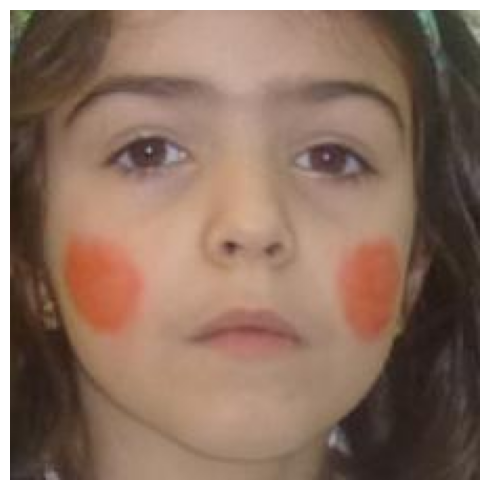

200


In [44]:
visualize_image(data['White'][0])
print(len(data['White']))

In [14]:
model = T2IModel("CompVis/stable-diffusion-v1-4", device="cuda:0", dtype="float16")

2025-10-29 22:33:42.947 | INFO     | t2Interp.T2I:__init__:108 - Enforcing eager attention implementation for attention pattern tracing. The HF default would be to use sdpa if available. To use sdpa, set attn_implementation='sdpa' or None to use the HF default.
Keyword arguments {'attn_implementation': 'eager', 'tokenizer_kwargs': {}, 'trust_remote_code': False} are not expected by StableDiffusionPipeline and will be ignored.
Loading pipeline components...: 100%|██████████| 6/6 [00:00<00:00, 20.95it/s]
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases t

In [ ]:
def preprocess_image_for_vae(image, target_size=512):
    transform = transforms.Compose([
        transforms.Resize((target_size, target_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5])  # Scale to [-1, 1]
    ])
    visualize_image(transform(image).unsqueeze(0))
    return transform(image).unsqueeze(0)

def encode_images_to_latents(model, images, batch_size=8):

    all_latents = []
    vae = model._model.pipeline.vae
    #This is getting the model's vae and encoding the data in that space
    device = next(vae.parameters()).device
    dtype = next(vae.parameters()).dtype  # Get VAE's dtype (float16 or float32)
    
    for i in range(0, len(images), batch_size):
        batch_images = images[i:i+batch_size]
        
        # Convert PIL images to tensors if needed
        if isinstance(batch_images[0], Image.Image):
            batch_tensors = torch.stack([
                preprocess_image_for_vae(img) for img in batch_images
            ]).squeeze(1)
        else:
            batch_tensors = torch.stack(batch_images)
        
        # Convert to correct device AND dtype to match VAE
        batch_tensors = batch_tensors.to(device=device, dtype=dtype)
        
        # Encode to latent space
        with torch.no_grad():
            latents = vae.encode(batch_tensors).latent_dist.sample()
            latents = latents * vae.config.scaling_factor
        
        all_latents.append(latents.cpu())
        
        # Free memory
        del batch_tensors
        torch.cuda.empty_cache()
    
    return torch.cat(all_latents, dim=0)


def batch_cache_image_activations(
    model,
    images: List[Image.Image],
    timestep: int = 500,
    batch_size: int = 4,
    encode_batch_size: int = 8,
):
    """
    Cache UNet activations from real images by encoding them and passing through UNet.
    
    This is useful for analyzing what the model "sees" in existing images,
    particularly for debiasing based on demographic attributes.
    
    Parameters:
    -----------
    model : T2IModel
    images : List[PIL.Image]
    layer_name : str
        The UNet layer/module to extract activations from
        Examples:
        - "unet.down_blocks[0].attentions[0].transformer_blocks[0].attn1.to_out[0].output"  # self-attn
        - "unet.down_blocks[0].attentions[0].transformer_blocks[0].attn2.to_out[0].output"  # cross-attn
        - "unet.mid_block.attentions[0].transformer_blocks[0].attn1.to_out[0].output"
        - "unet.down_blocks[0].resnets[0].output"  # ResNet blocks
    timestep : int
        Timestep to use for the forward pass (controls noise level)
    batch_size : int
        Number of images to process in each forward pass
    encode_batch_size : int
        Batch size for VAE encoding
    
    """
    
    print(f"Encoding {len(images)} images to latent space...")
    latents = encode_images_to_latents(model, images, batch_size=encode_batch_size)
    
    device = next(model._model.pipeline.unet.parameters()).device
    all_activations = []
    
    # Get text embeddings (empty for unconditional)

    text_embeds = model._model.pipeline.encode_prompt(
        prompt="",
        device=device,
        num_images_per_prompt=1,
        do_classifier_free_guidance=False
    )[0]

    # Create timestep tensor
    t = torch.tensor([timestep], device=device, dtype=torch.long)
    
    # Get UNet dtype
    unet_dtype = next(model._model.pipeline.unet.parameters()).dtype
    print(repr(model._model.pipeline.unet))

    for i in tqdm(range(0, len(latents), batch_size), desc="Processing batches"):
        batch_latents = latents[i:i+batch_size].to(device=device, dtype=unet_dtype)
        batch_size_actual = batch_latents.shape[0]
        
        # Expand text embeddings to match batch size
        batch_text_embeds = text_embeds.repeat(batch_size_actual, 1, 1)
        
        # Forward pass through UNet (hook will capture activation)
        with torch.no_grad():
            unet_output = model._model.pipeline.unet(
                batch_latents,
                t,
                encoder_hidden_states=batch_text_embeds,
                return_dict=False
            )
            
            # Get the captured activation
            act = unet_output[0]
            #this is detaching over batch and channel
            single_act = act[0][0].detach().float().cpu()
            print("the shape of a single activation is", single_act[0].shape)
            visualize_image(single_act)
            print("the shape of the activation is", act.shape)
            act = act.flatten(start_dim=1)
            all_activations.append(act.cpu().numpy())
        
        # Clear memory
        del batch_latents, batch_text_embeds, unet_output
        torch.cuda.empty_cache()

    
    activations = np.concatenate(all_activations, axis=0)
    print(f"Final activation shape: {activations.shape}")
    
    return activations


def batch_cache_image_activations_by_class(
    model,
    images_dict: Dict[str, List[Image.Image]],
    timestep: int = 500,
    batch_size: int = 4,
    encode_batch_size: int = 8,
    max_images_per_class: Optional[int] = None,

):

    activations_dict = {}
    
    for class_name, images in images_dict.items():
        # Limit images if specified
        if max_images_per_class is not None:
            images = images[:max_images_per_class]
        
        print(f"\n{'='*60}")
        print(f"Processing class: {class_name} ({len(images)} images)")
        print(f"{'='*60}")
        
        activations_dict[class_name] = batch_cache_image_activations(
            model=model,
            images=images,
            timestep=timestep,
            batch_size=batch_size,
            encode_batch_size=encode_batch_size,
        )
    
    return activations_dict


Processing class: Black (200 images)
Encoding 200 images to latent space...
UNet2DConditionModel(
  (conv_in): Conv2d(4, 320, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (time_proj): Timesteps()
  (time_embedding): TimestepEmbedding(
    (linear_1): Linear(in_features=320, out_features=1280, bias=True)
    (act): SiLU()
    (linear_2): Linear(in_features=1280, out_features=1280, bias=True)
  )
  (down_blocks): ModuleList(
    (0): CrossAttnDownBlock2D(
      (attentions): ModuleList(
        (0-1): 2 x Transformer2DModel(
          (norm): GroupNorm(32, 320, eps=1e-06, affine=True)
          (proj_in): Conv2d(320, 320, kernel_size=(1, 1), stride=(1, 1))
          (transformer_blocks): ModuleList(
            (0): BasicTransformerBlock(
              (norm1): LayerNorm((320,), eps=1e-05, elementwise_affine=True)
              (attn1): Attention(
                (to_q): Linear(in_features=320, out_features=320, bias=False)
                (to_k): Linear(in_features=320, out_fea

Processing batches:   0%|          | 0/4 [00:00<?, ?it/s]

the shape of a single activation is torch.Size([64])


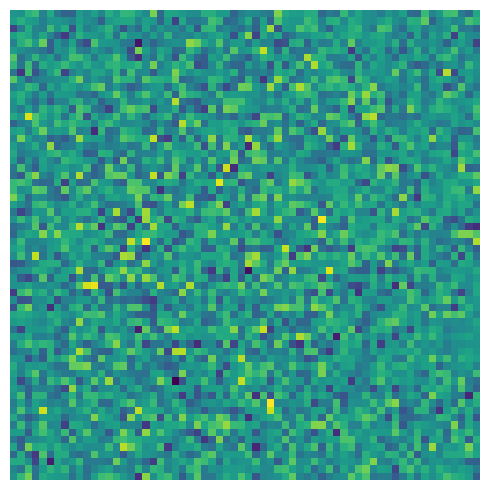

Processing batches:  25%|██▌       | 1/4 [00:00<00:00,  4.12it/s]

the shape of the activation is torch.Size([64, 4, 64, 64])
the shape of a single activation is torch.Size([64])


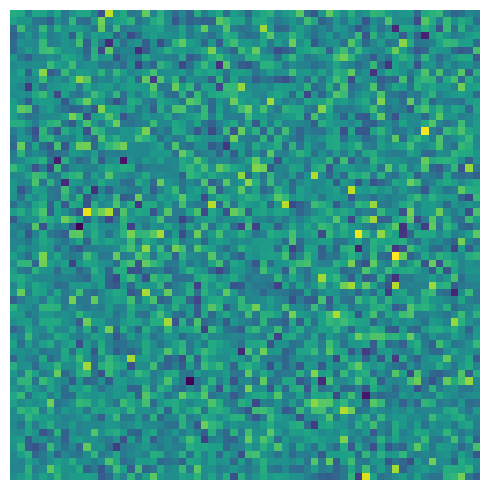

Processing batches:  50%|█████     | 2/4 [00:00<00:00,  4.11it/s]

the shape of the activation is torch.Size([64, 4, 64, 64])
the shape of a single activation is torch.Size([64])


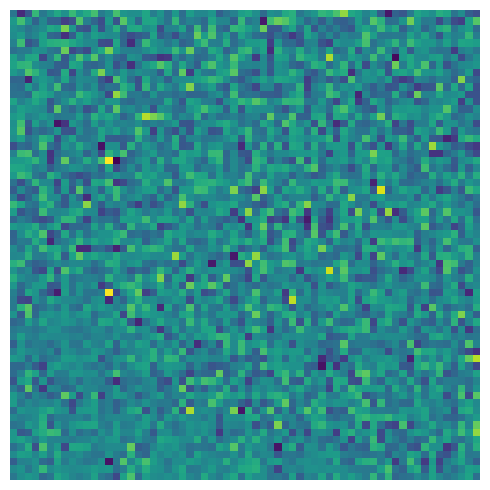

Processing batches:  75%|███████▌  | 3/4 [00:00<00:00,  4.11it/s]

the shape of the activation is torch.Size([64, 4, 64, 64])
the shape of a single activation is torch.Size([64])


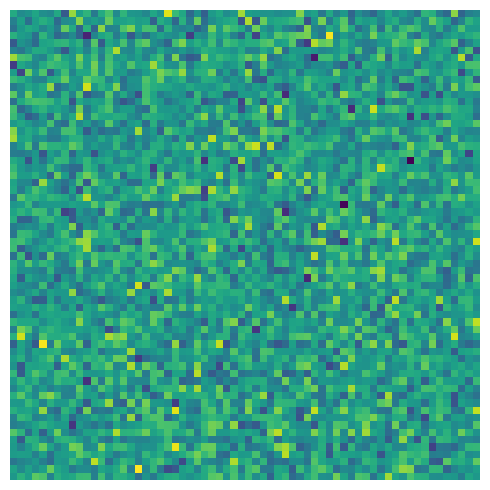

Processing batches: 100%|██████████| 4/4 [00:00<00:00,  4.93it/s]

the shape of the activation is torch.Size([8, 4, 64, 64])
Final activation shape: (200, 16384)

Processing class: East_Asian (200 images)
Encoding 200 images to latent space...


UNet2DConditionModel(
  (conv_in): Conv2d(4, 320, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (time_proj): Timesteps()
  (time_embedding): TimestepEmbedding(
    (linear_1): Linear(in_features=320, out_features=1280, bias=True)
    (act): SiLU()
    (linear_2): Linear(in_features=1280, out_features=1280, bias=True)
  )
  (down_blocks): ModuleList(
    (0): CrossAttnDownBlock2D(
      (attentions): ModuleList(
        (0-1): 2 x Transformer2DModel(
          (norm): GroupNorm(32, 320, eps=1e-06, affine=True)
          (proj_in): Conv2d(320, 320, kernel_size=(1, 1), stride=(1, 1))
          (transformer_blocks): ModuleList(
            (0): BasicTransformerBlock(
              (norm1): LayerNorm((320,), eps=1e-05, elementwise_affine=True)
              (attn1): Attention(
                (to_q): Linear(in_features=320, out_features=320, bias=False)
                (to_k): Linear(in_features=320, out_features=320, bias=False)
                (to_v): Linear(in_features=320, out_fe

Processing batches:   0%|          | 0/4 [00:00<?, ?it/s]

the shape of a single activation is torch.Size([64])


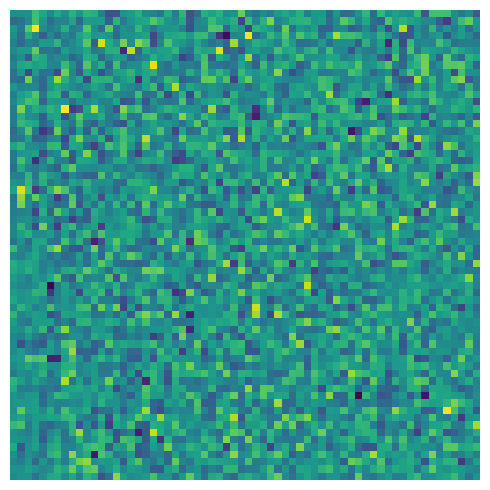

Processing batches:  25%|██▌       | 1/4 [00:00<00:00,  4.12it/s]

the shape of the activation is torch.Size([64, 4, 64, 64])
the shape of a single activation is torch.Size([64])


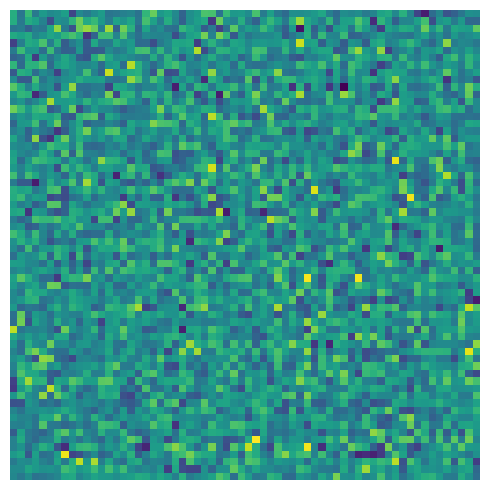

Processing batches:  50%|█████     | 2/4 [00:00<00:00,  4.12it/s]

the shape of the activation is torch.Size([64, 4, 64, 64])
the shape of a single activation is torch.Size([64])


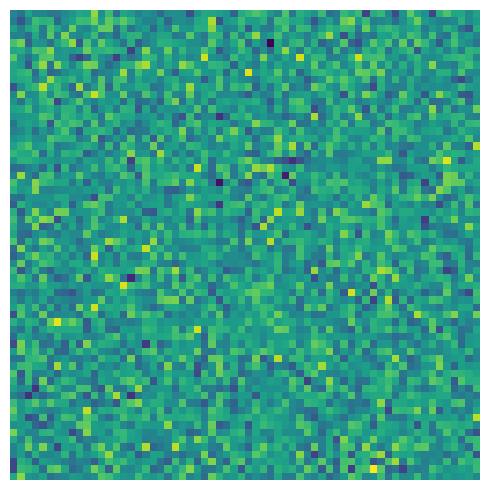

Processing batches:  75%|███████▌  | 3/4 [00:00<00:00,  4.14it/s]

the shape of the activation is torch.Size([64, 4, 64, 64])
the shape of a single activation is torch.Size([64])


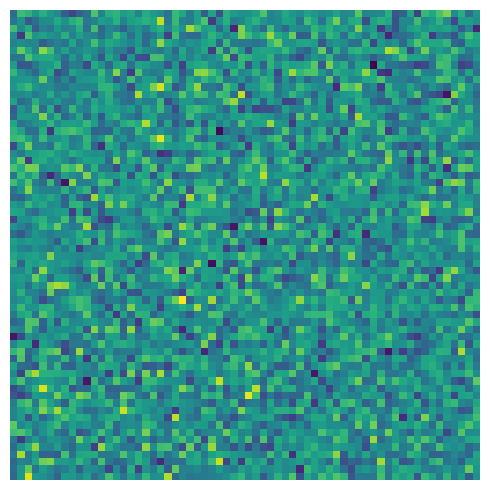

Processing batches: 100%|██████████| 4/4 [00:00<00:00,  4.95it/s]

the shape of the activation is torch.Size([8, 4, 64, 64])
Final activation shape: (200, 16384)

Processing class: Indian (200 images)
Encoding 200 images to latent space...


UNet2DConditionModel(
  (conv_in): Conv2d(4, 320, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (time_proj): Timesteps()
  (time_embedding): TimestepEmbedding(
    (linear_1): Linear(in_features=320, out_features=1280, bias=True)
    (act): SiLU()
    (linear_2): Linear(in_features=1280, out_features=1280, bias=True)
  )
  (down_blocks): ModuleList(
    (0): CrossAttnDownBlock2D(
      (attentions): ModuleList(
        (0-1): 2 x Transformer2DModel(
          (norm): GroupNorm(32, 320, eps=1e-06, affine=True)
          (proj_in): Conv2d(320, 320, kernel_size=(1, 1), stride=(1, 1))
          (transformer_blocks): ModuleList(
            (0): BasicTransformerBlock(
              (norm1): LayerNorm((320,), eps=1e-05, elementwise_affine=True)
              (attn1): Attention(
                (to_q): Linear(in_features=320, out_features=320, bias=False)
                (to_k): Linear(in_features=320, out_features=320, bias=False)
                (to_v): Linear(in_features=320, out_fe

Processing batches:   0%|          | 0/4 [00:00<?, ?it/s]

the shape of a single activation is torch.Size([64])


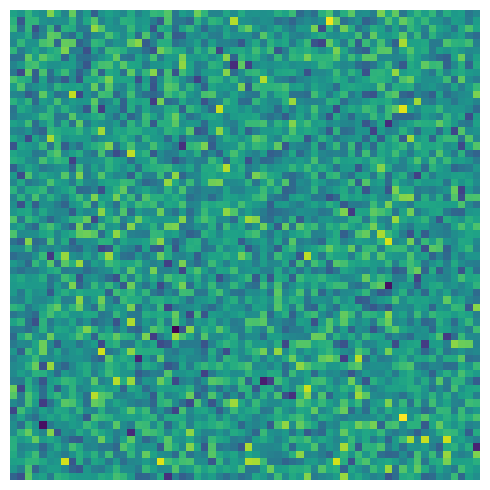

Processing batches:  25%|██▌       | 1/4 [00:00<00:00,  4.07it/s]

the shape of the activation is torch.Size([64, 4, 64, 64])
the shape of a single activation is torch.Size([64])


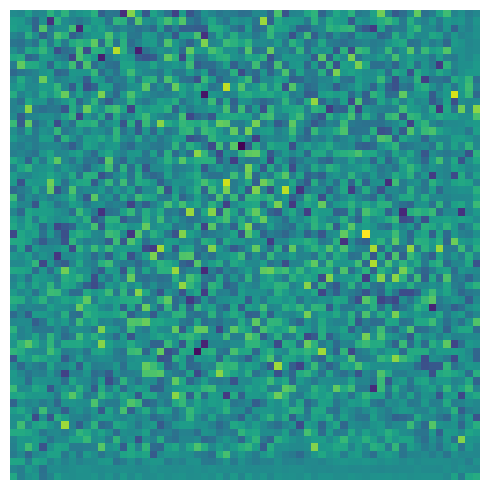

Processing batches:  50%|█████     | 2/4 [00:00<00:00,  4.13it/s]

the shape of the activation is torch.Size([64, 4, 64, 64])
the shape of a single activation is torch.Size([64])


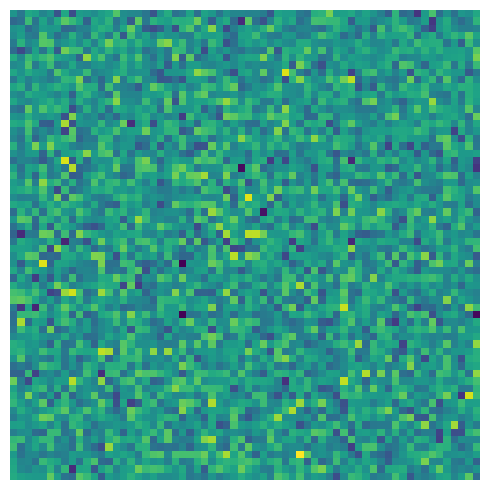

Processing batches:  75%|███████▌  | 3/4 [00:00<00:00,  4.12it/s]

the shape of the activation is torch.Size([64, 4, 64, 64])
the shape of a single activation is torch.Size([64])


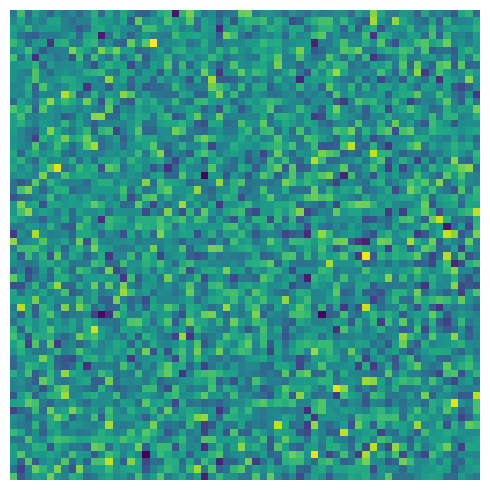

Processing batches: 100%|██████████| 4/4 [00:00<00:00,  4.91it/s]

the shape of the activation is torch.Size([8, 4, 64, 64])
Final activation shape: (200, 16384)

Processing class: Latino_Hispanic (200 images)
Encoding 200 images to latent space...


KeyboardInterrupt: 

In [73]:
activations_by_ethnicity = batch_cache_image_activations_by_class(
    model=model,
    images_dict=data,  # <-- Using REAL IMAGES, not prompts
    timestep=50,  # Noise level for UNet forward pass
    batch_size=64,
    encode_batch_size=64,
)

print("\n✓ Training on flattened spatial representations")
print(f"✓ Each image is one sample with S*C features")
for k, v in activations_by_ethnicity.items():
    print(f"  {k}: {v.shape}")

the shape of the image encodings is torch.Size([4, 64, 64])


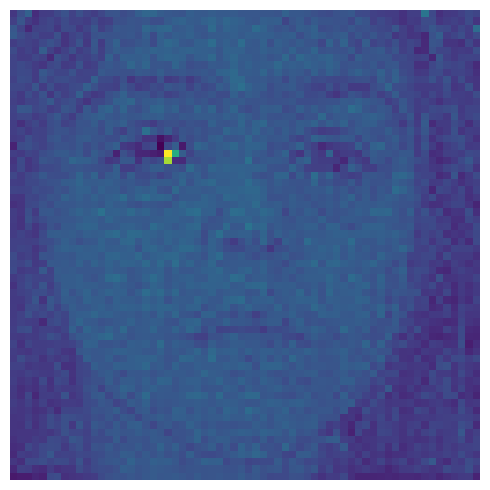

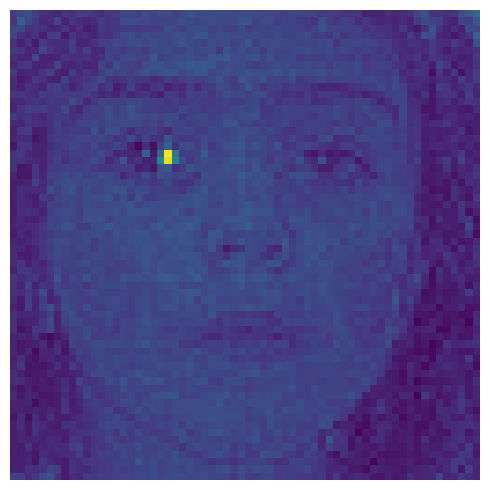

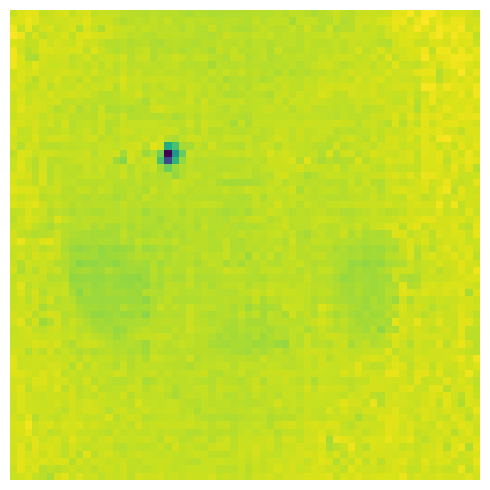

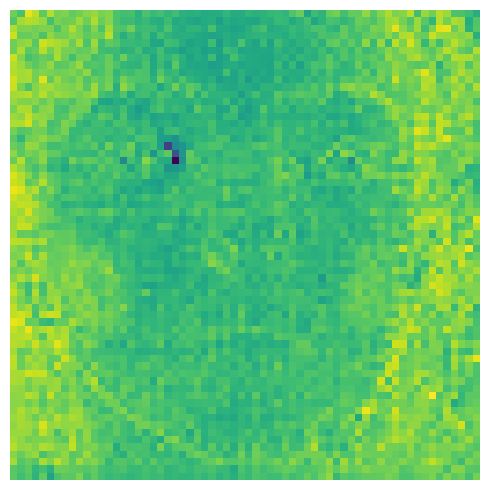

In [72]:
image_encodings = encode_images_to_latents(model, data['White'])
an_image_encoding = image_encodings[0]

print("the shape of the image encodings is", an_image_encoding.shape)
for i in range(an_image_encoding.shape[0]):
    visualize_image(an_image_encoding[i])


In [74]:
print(repr(model._model))

Diffuser(
  (vae): AutoencoderKL(
    (encoder): Encoder(
      (conv_in): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (down_blocks): ModuleList(
        (0): DownEncoderBlock2D(
          (resnets): ModuleList(
            (0-1): 2 x ResnetBlock2D(
              (norm1): GroupNorm(32, 128, eps=1e-06, affine=True)
              (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
              (norm2): GroupNorm(32, 128, eps=1e-06, affine=True)
              (dropout): Dropout(p=0.0, inplace=False)
              (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
              (nonlinearity): SiLU()
            )
          )
          (downsamplers): ModuleList(
            (0): Downsample2D(
              (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(2, 2))
            )
          )
        )
        (1): DownEncoderBlock2D(
          (resnets): ModuleList(
            (0): ResnetBlock2D(
             

In [ ]:
#make a method that processes text in the T2I and displays the output of the visual encoder
def process_text_in_T2I(text, model):
    text_embeds = model._model.pipeline.encode_prompt(
        prompt=text,
        device=device,
        num_images_per_prompt=1,
        do_classifier_free_guidance=False
    )[0]

In [26]:
input_dim = activations_by_ethnicity['Black'].shape[-1]
num_classes = len(activations_by_ethnicity)

print(f"Input dimension: {input_dim}")
print(f"Number of classes: {num_classes}")
print(f"Classes: {list(activations_by_ethnicity.keys())}")

# Initialize and train the classifier
classifier = K_Steering(
    input_dim=input_dim,
    num_classes=num_classes,
    hidden_dim=256,
    lr=1e-3,
    device='cuda'
)

# Train on the cached activations
classifier.fit(
    activations_dict=activations_by_ethnicity,
    epochs=100,
    batch_size=4
)

print("\nClassifier trained! You can now use it for debiasing.")

Input dimension: 16384
Number of classes: 7
Classes: ['Black', 'East_Asian', 'Indian', 'Latino_Hispanic', 'Middle_Eastern', 'Southeast_Asian', 'White']
Train: 1120, Val: 280
Epoch 0: Loss=1.9349, Train=18.6%, Val=22.9%
Epoch 1: Loss=0.8735, Train=69.5%, Val=21.8%
Epoch 2: Loss=0.0939, Train=97.0%, Val=22.5%
Epoch 3: Loss=0.0045, Train=100.0%, Val=23.9%
Epoch 4: Loss=0.0005, Train=100.0%, Val=22.9%
Epoch 5: Loss=0.0003, Train=100.0%, Val=23.2%
Epoch 6: Loss=0.0002, Train=100.0%, Val=23.6%
Epoch 7: Loss=0.0002, Train=100.0%, Val=23.6%
Epoch 8: Loss=0.0001, Train=100.0%, Val=23.9%
Epoch 9: Loss=0.0001, Train=100.0%, Val=23.9%
Epoch 10: Loss=0.0001, Train=100.0%, Val=23.9%
Epoch 11: Loss=0.0001, Train=100.0%, Val=23.9%
Epoch 12: Loss=0.0001, Train=100.0%, Val=23.9%
Epoch 13: Loss=0.0000, Train=100.0%, Val=23.6%
Epoch 14: Loss=0.0000, Train=100.0%, Val=24.6%
Epoch 15: Loss=0.0000, Train=100.0%, Val=24.3%
Epoch 16: Loss=0.0000, Train=100.0%, Val=25.0%
Epoch 17: Loss=0.0000, Train=100.0%, Val

KeyboardInterrupt: 